In [35]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score
from sklearn.compose import make_column_selector

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [7]:
df = pd.read_csv(r'../../Datasets/concrete_data.csv')

df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [27]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [32]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Strength']), df['Strength'], test_size=0.3, random_state=False)

X_train_df = pd.DataFrame(X_train, columns=X_train.columns)

### before box-cox transformation

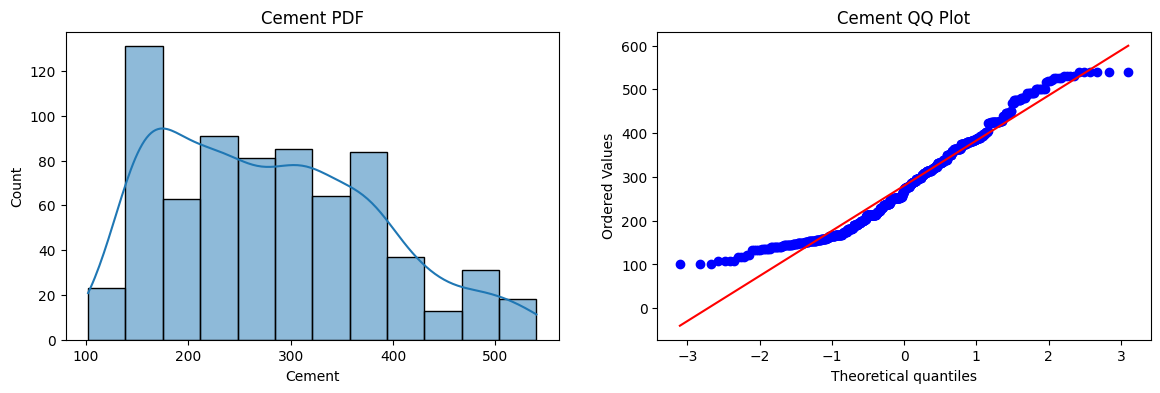

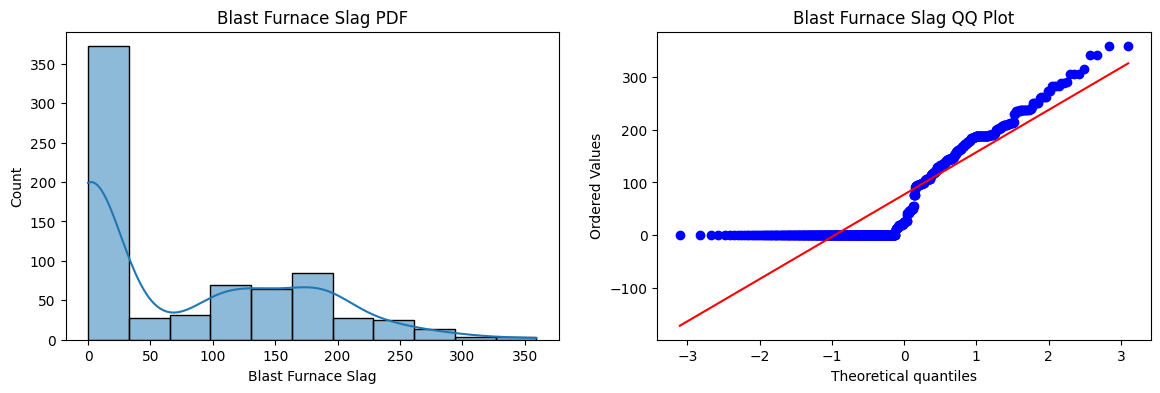

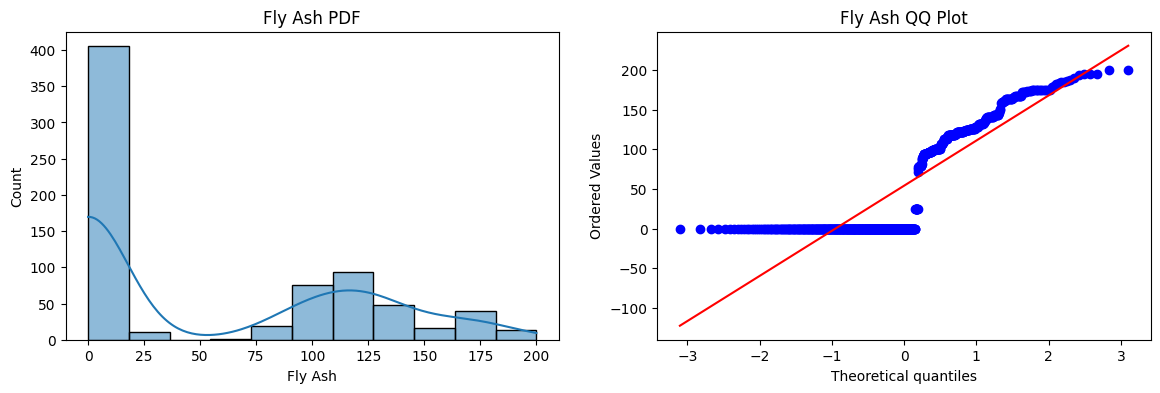

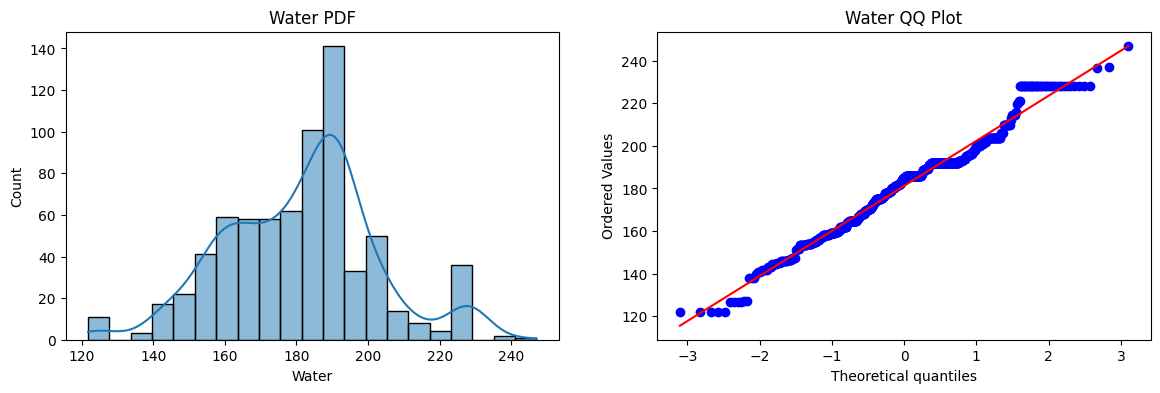

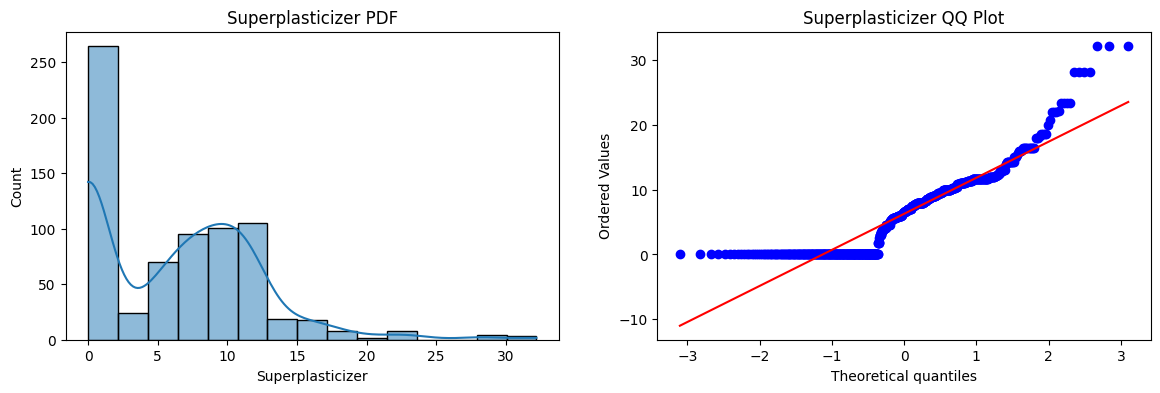

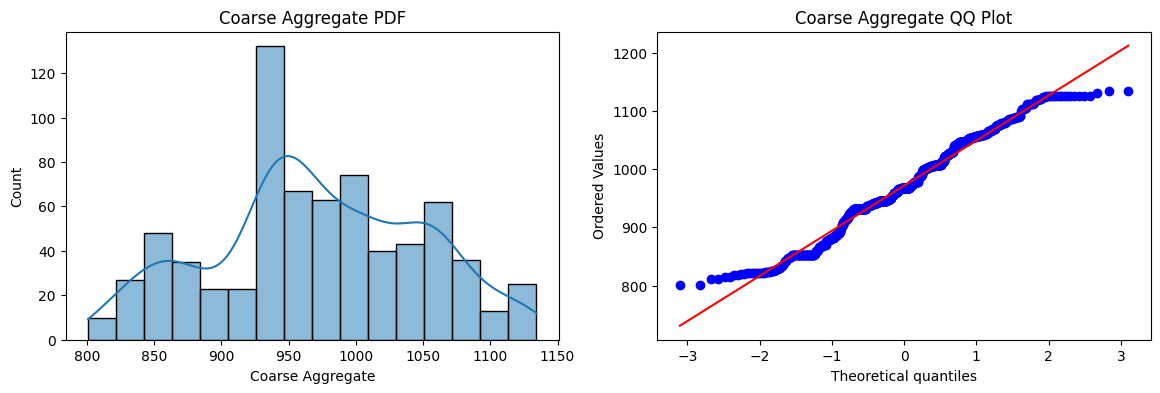

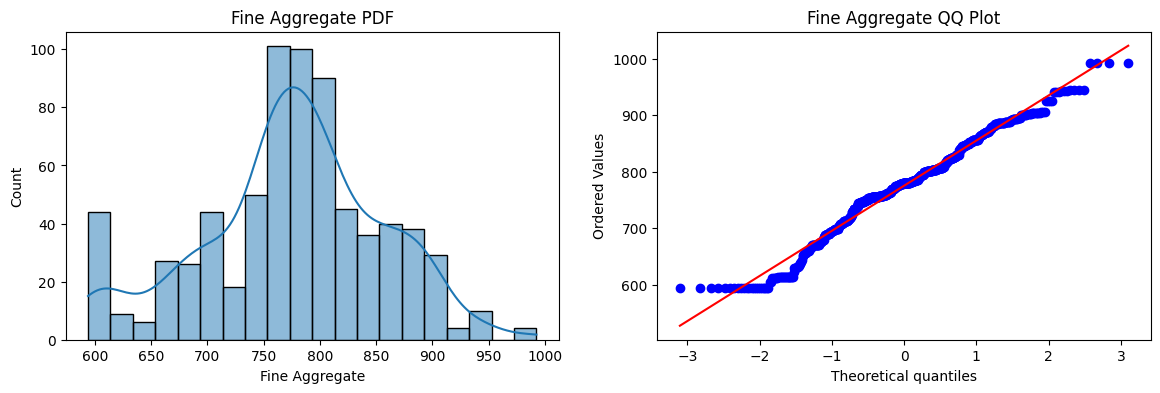

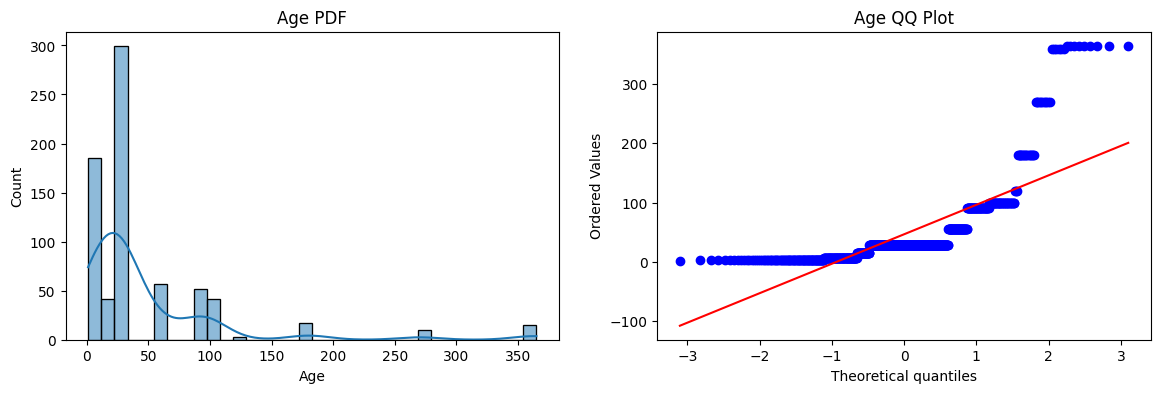

In [51]:

columns =['Cement',	'Blast Furnace Slag',	'Fly Ash',	'Water',	'Superplasticizer',	'Coarse Aggregate',	'Fine Aggregate',	'Age'	]

for column in columns:
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    sns.histplot(X_train_df[column], kde=True)
    plt.title(f'{column} PDF')

    # Right plot: Q-Q plot
    plt.subplot(122)
    stats.probplot(X_train_df[column], dist='norm', plot=plt)
    plt.title(f'{column} QQ Plot')

    plt.show()


# left skewed: cement, Coarse Aggregate, Fine Aggregate
# right skewed: water , age, Superplasticizer

In [52]:
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("R2 Score before transformation:", r2_score(y_test, y_pred))

R2 Score before transformation: 0.6352987285077925


In [57]:
from sklearn.model_selection import KFold, cross_val_score

# cross validation on training set before transformation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_before = cross_val_score(lr, X_train, y_train, cv=kf, scoring='r2')
print("CV R2 before transformation: mean {:.4f}, std {:.4f}".format(scores_before.mean(), scores_before.std()))
print('Cross val score: ', scores_before)

CV R2 before transformation: mean 0.5890, std 0.0730
Cross val score:  [0.66636973 0.67692985 0.4838678  0.55273484 0.56485235]


In [53]:
transformer = PowerTransformer(method='box-cox')

X_train_transformed = transformer.fit_transform(X_train+0.00000001)
X_test_transformed = transformer.transform(X_test+0.00000001)

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=transformer.get_feature_names_out())

### After Box-Cox transformation

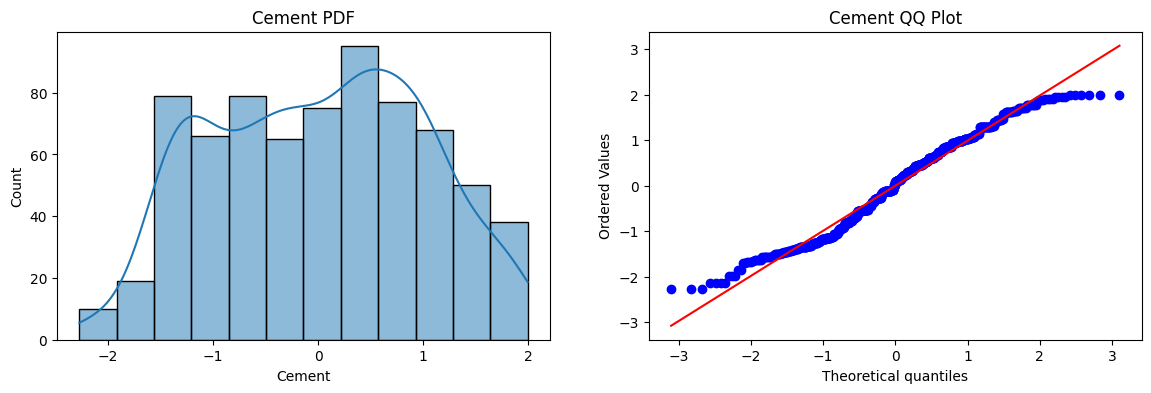

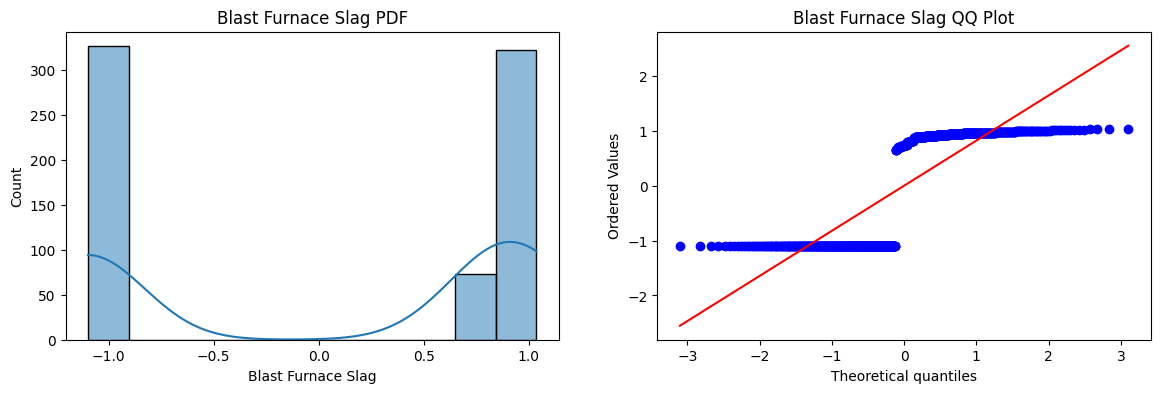

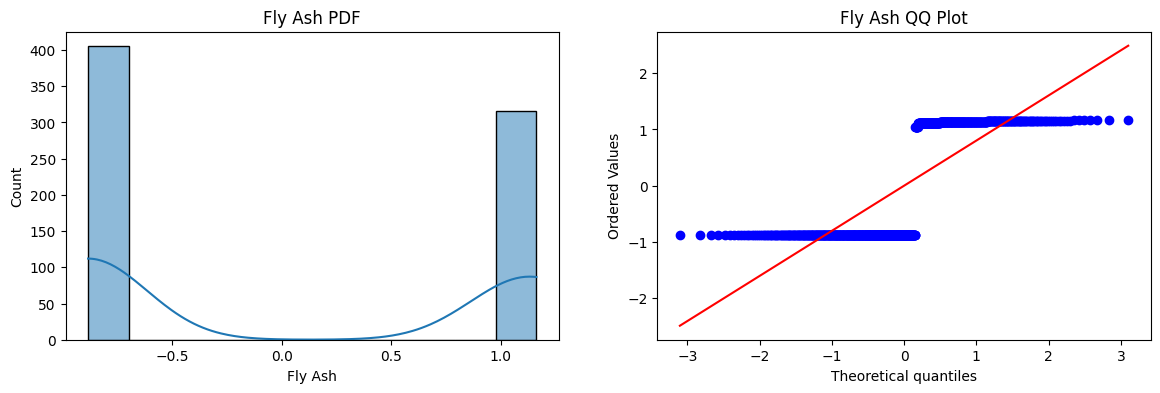

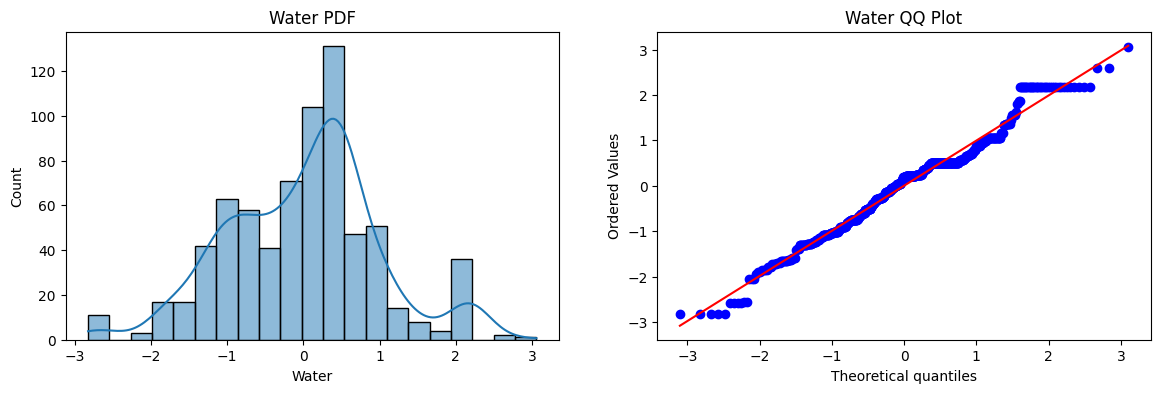

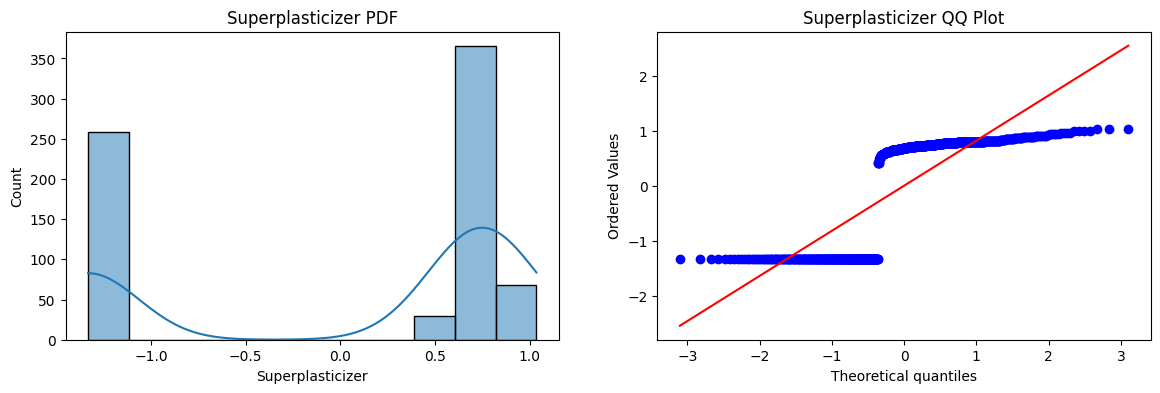

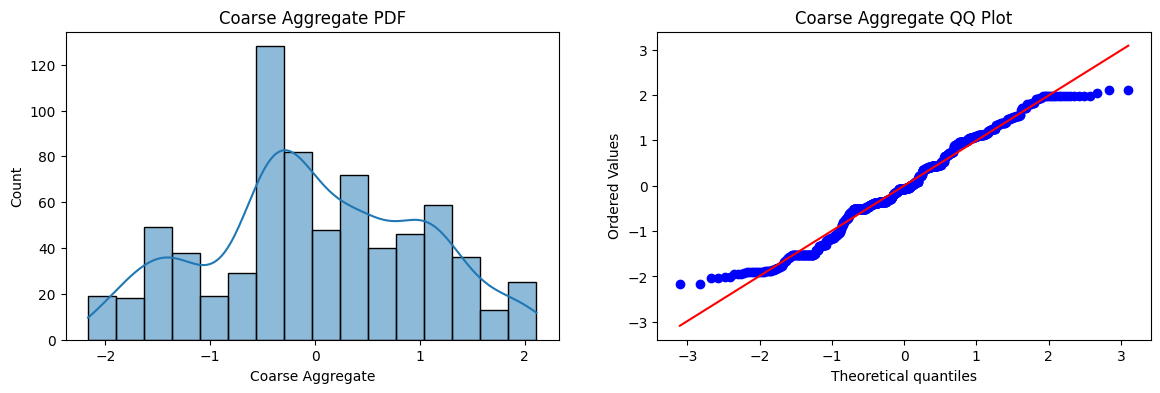

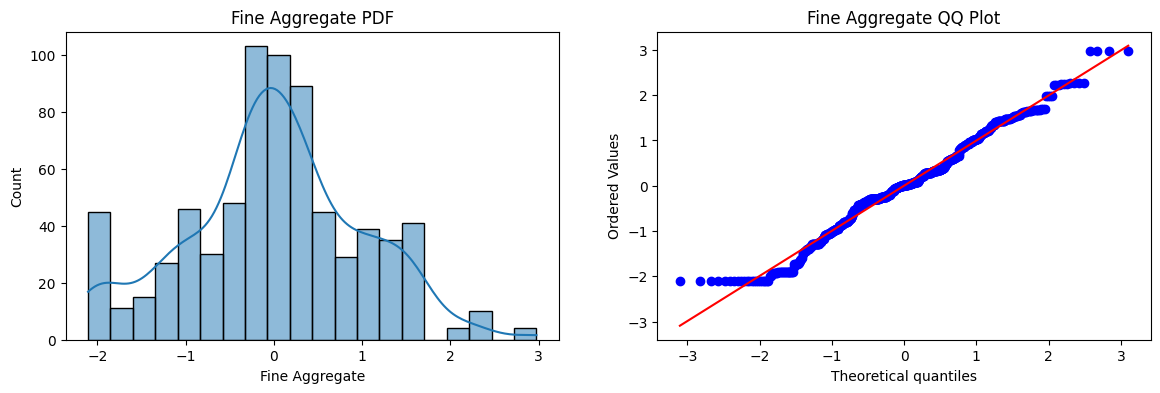

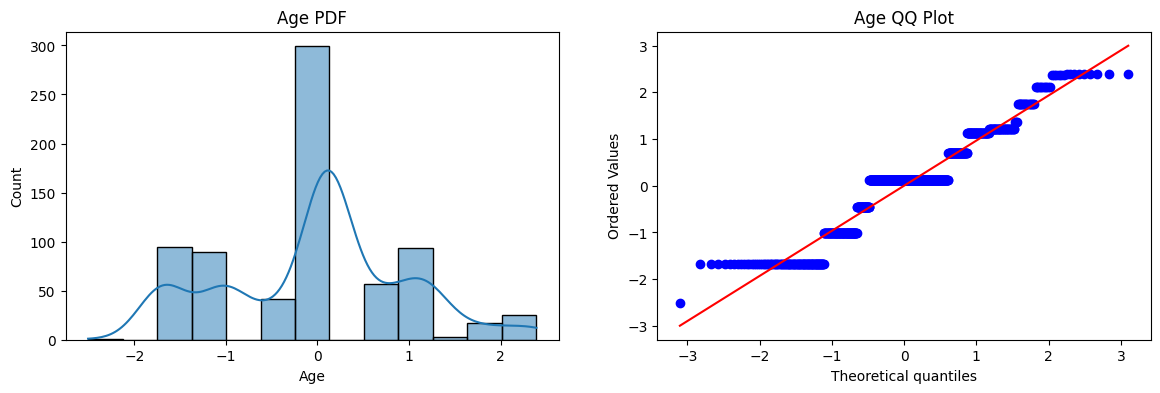

In [54]:

for column in columns:
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    sns.histplot(X_train_transformed_df[column], kde=True)
    plt.title(f'{column} PDF')

    # Right plot: Q-Q plot
    plt.subplot(122)
    stats.probplot(X_train_transformed_df[column], dist='norm', plot=plt)
    plt.title(f'{column} QQ Plot')

    plt.show()

In [55]:
lr2 = LinearRegression()

lr2.fit(X_train_transformed, y_train)
y_pred_transformed = lr2.predict(X_test_transformed)

print('r2 score after transformation: ', r2_score(y_true=y_test, y_pred=y_pred_transformed))

r2 score after transformation:  0.8164826891078999


In [58]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('pt', PowerTransformer(method='box-cox')),
    ('lr', LinearRegression())
])

# cross validation on training set after transformation using pipeline
scores_after = cross_val_score(pipe, X_train+1e-8, y_train, cv=kf, scoring='r2')
print("CV R2 after transformation: mean {:.4f}, std {:.4f}".format(scores_after.mean(), scores_after.std()))
print('Cross val score: ', scores_before)

CV R2 after transformation: mean 0.7872, std 0.0273
Cross val score:  [0.66636973 0.67692985 0.4838678  0.55273484 0.56485235]


## Applying Yeo-Johnson transform

In [59]:
yeo_transformer = PowerTransformer()

X_train_yeo_transformed = yeo_transformer.fit_transform(X_train)
X_test_yeo_transformed = yeo_transformer.transform(X_test)

X_train_yeo_transformed_df = pd.DataFrame(X_train_yeo_transformed, columns=yeo_transformer.get_feature_names_out())

#### After yeo transformation 

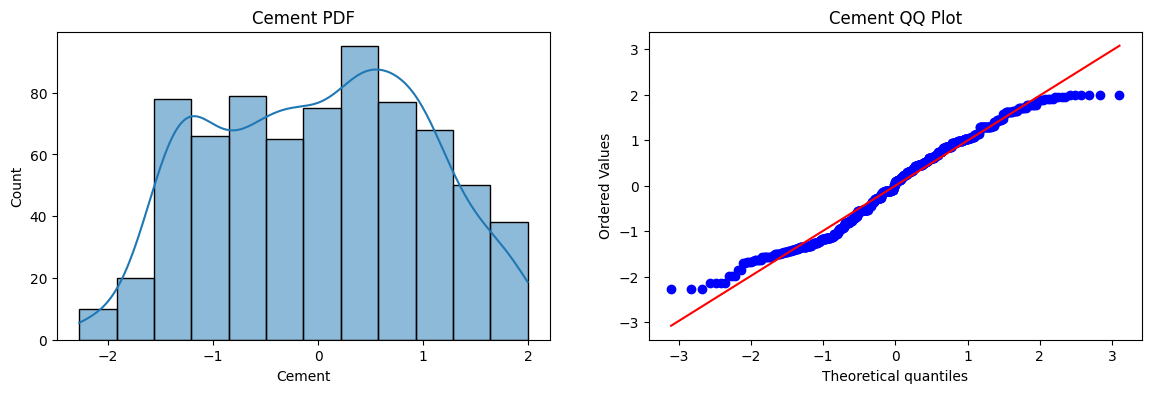

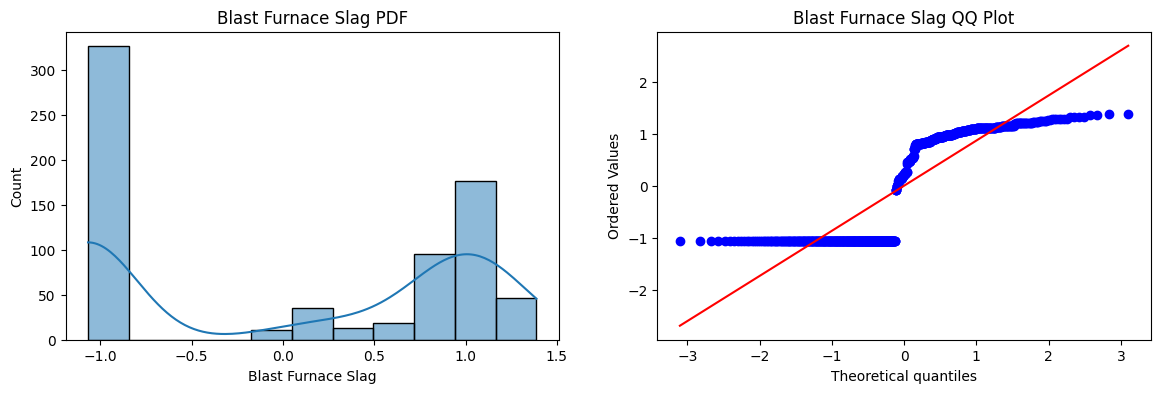

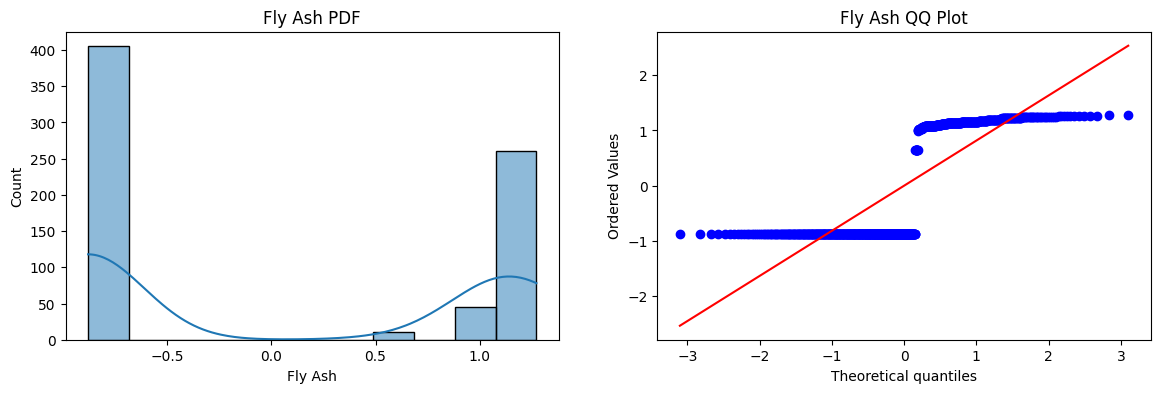

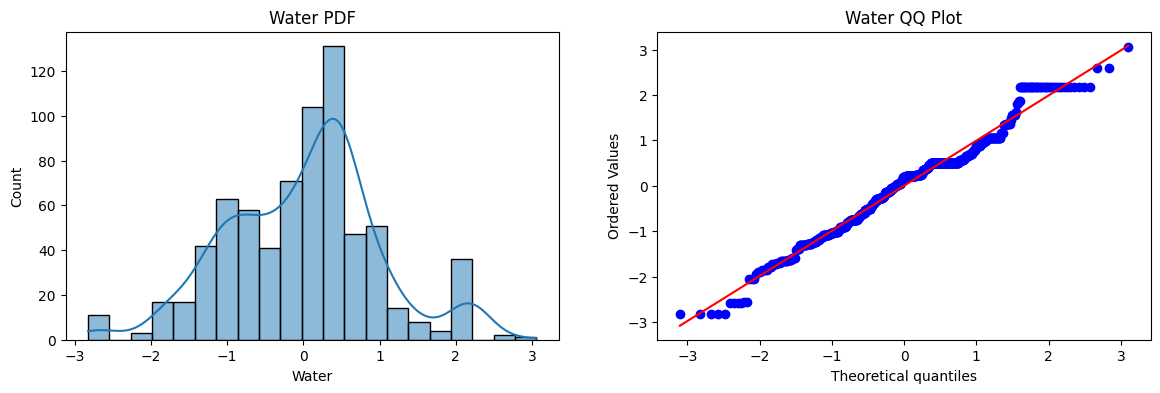

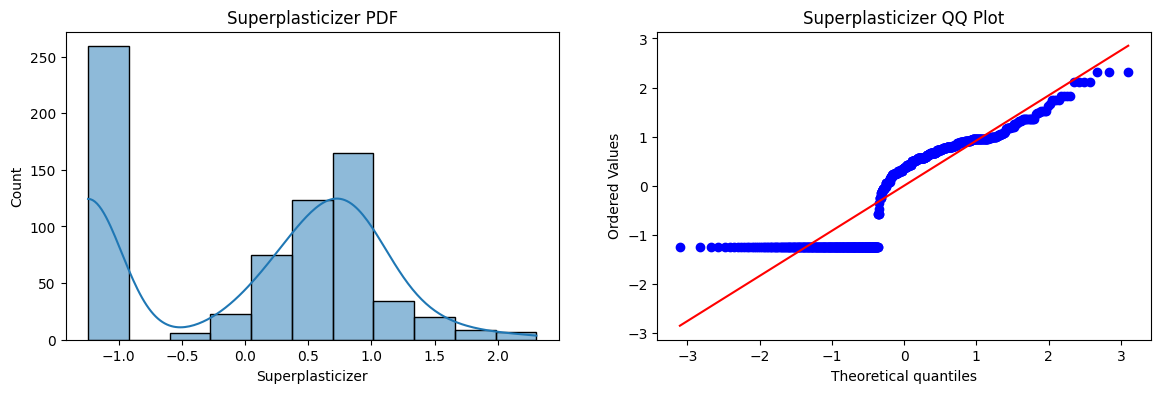

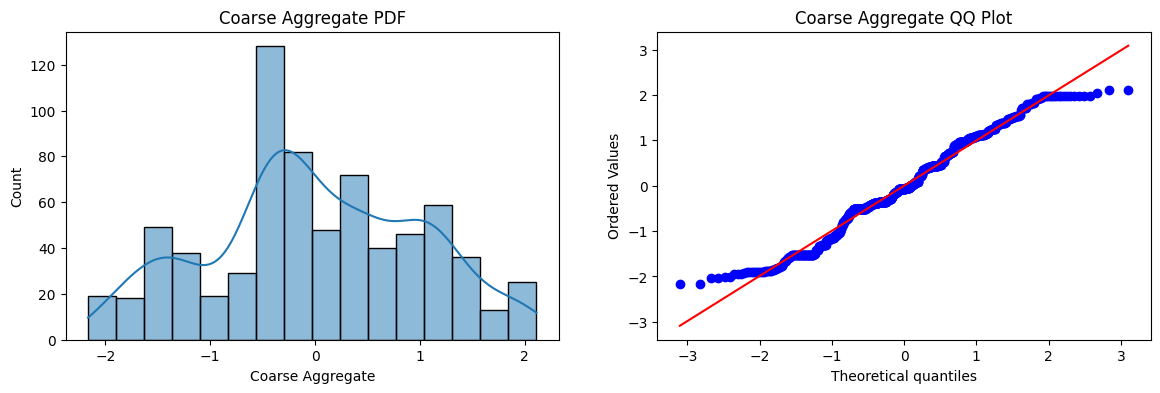

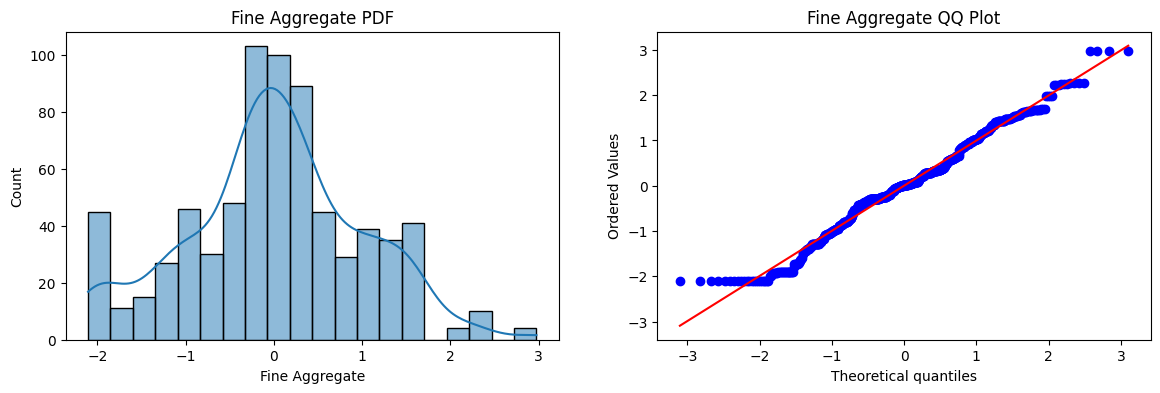

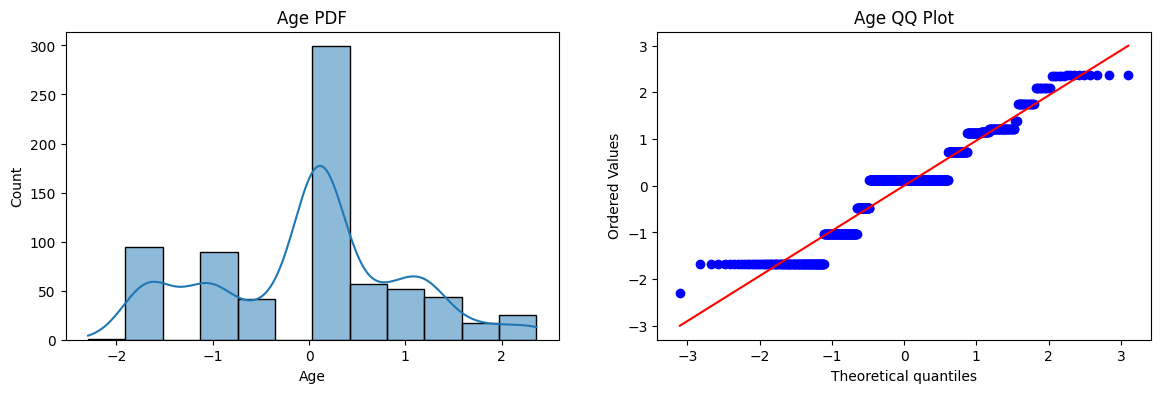

In [60]:

for column in columns:
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    sns.histplot(X_train_yeo_transformed_df[column], kde=True)
    plt.title(f'{column} PDF')

    # Right plot: Q-Q plot
    plt.subplot(122)
    stats.probplot(X_train_yeo_transformed_df[column], dist='norm', plot=plt)
    plt.title(f'{column} QQ Plot')

    plt.show()

In [61]:
lr2 = LinearRegression()

lr2.fit(X_train_yeo_transformed, y_train)
y_pred_yeo_transformed = lr2.predict(X_test_yeo_transformed)

print('r2 score after yeo transformation: ', r2_score(y_true=y_test, y_pred=y_pred_yeo_transformed))

r2 score after yeo transformation:  0.8250136896132594


In [65]:
from sklearn.pipeline import Pipeline

yeo_pipe = Pipeline([
    ('pt', PowerTransformer()),
    ('lr', LinearRegression())
])

# cross validation on training set after transformation using pipeline
yeo_scores_after = cross_val_score(yeo_pipe, X_train_yeo_transformed, y_train, cv=kf, scoring='r2')
print("CV R2 after transformation: mean {:.4f}, std {:.4f}".format(yeo_scores_after.mean(), yeo_scores_after.std()))
print('Cross val score: ', yeo_scores_after)

CV R2 after transformation: mean 0.7875, std 0.0283
Cross val score:  [0.81855576 0.82271463 0.77788374 0.76625414 0.75206481]


In [66]:
pd.DataFrame({'cols': X_train.columns, 'box-cox lambdas': transformer.lambdas_, 'yeo-jhonson lambdas': yeo_transformer.lambdas_})

,cols,box-cox lambdas,yeo-jhonson lambdas
0,Cement,0.183828,0.181196
1,Blast Furnace Slag,0.023538,0.028011
2,Fly Ash,-0.032326,-0.165526
3,Water,0.925279,0.924736
4,Superplasticizer,0.084224,0.286946
5,Coarse Aggregate,1.144747,1.145007
6,Fine Aggregate,1.771619,1.772672
7,Age,0.041458,-0.005485
